In [34]:
from dotenv import load_dotenv
load_dotenv()

from typing_extensions import TypedDict
from typing import Annotated

from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from IPython.display import Image, display

In [35]:
llm = init_chat_model("google_genai:gemini-2.5-flash")

In [36]:
class State(TypedDict):
    application: str
    experience_level: str
    skill_match: str
    response: str

In [37]:
def categorize_experience(state: State):

    prompt = ChatPromptTemplate.from_template("""
    Categorize candidate as:
    - Entry-level
    - Mid-level
    - Senior-level

    Application:
    {application}
    """)

    chain = prompt | llm
    result = chain.invoke({"application": state["application"]})

    return {"experience_level": result.content.strip()}

In [38]:
def assess_skillset(state: State):

    prompt = ChatPromptTemplate.from_template("""
    Check Python skills in the application.

    Return only:
    Match OR No Match

    Application:
    {application}
    """)

    chain = prompt | llm
    result = chain.invoke({"application": state["application"]})

    return {"skill_match": result.content.strip()}

In [39]:
def schedule_hr_interview(state: State):
    return {"response": "Shortlisted for HR interview."}


def escalate_to_recruiter(state: State):
    return {"response": "Senior candidate but missing Python skills."}


def reject_application(state: State):
    return {"response": "Candidate rejected."}

In [40]:
def route_application(state: State):

    skill = state["skill_match"].lower()
    exp = state["experience_level"].lower()

    if skill == "match":
        return "schedule"
    elif exp == "senior-level":
        return "escalate"
    else:
        return "reject"

In [41]:
builder = StateGraph(State)

builder.add_node("categorize_experience", categorize_experience)
builder.add_node("assess_skillset", assess_skillset)
builder.add_node("schedule_hr_interview", schedule_hr_interview)
builder.add_node("escalate_to_recruiter", escalate_to_recruiter)
builder.add_node("reject_application", reject_application)


builder.add_edge(START, "categorize_experience")
builder.add_edge("categorize_experience", "assess_skillset")

builder.add_conditional_edges(
    "assess_skillset",
    route_application,
    {
        "schedule": "schedule_hr_interview",
        "escalate": "escalate_to_recruiter",
        "reject": "reject_application"
    }
)

builder.add_edge("schedule_hr_interview", END)
builder.add_edge("escalate_to_recruiter", END)
builder.add_edge("reject_application", END)

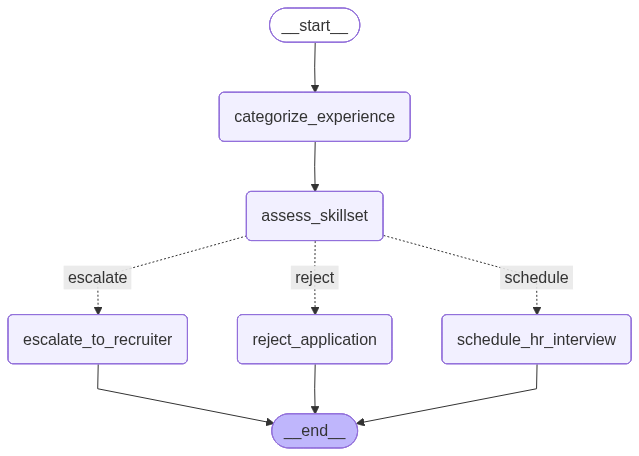

In [42]:
app = builder.compile()

display(Image(app.get_graph().draw_mermaid_png()))

In [43]:
def run_candidate_screening(application: str):

    result = app.invoke({
        "application": application
    })

    return result

In [44]:
application_text = """
5 years experience in Python, Data Analysis, AWS, Docker.
"""

result = run_candidate_screening(application_text)

print("Experience Level:", result["experience_level"])
print("Skill Match:", result["skill_match"])
print("Response:", result["response"])

Experience Level: **Mid-level**

With 5 years of experience in relevant technologies like Python, Data Analysis, AWS, and Docker, the candidate has moved beyond entry-level and likely possesses a solid understanding, can work independently on complex tasks, and contribute to design and architecture. They may also be able to mentor more junior team members. Senior-level typically implies 8+ years of experience, often with a focus on leadership, architectural design, and strategic technical direction.
Skill Match: Match
Response: Shortlisted for HR interview.
